# stochastic logistic model
model from Descheemaeker et al. eLife 2020
Here we generate 
- I1: logistic growth model
- I2 - I5: stochastic logistic model with increasing extrinsic noise (fluctuation in growth rates due to environmental fluctuations; linear multiplicative noise)
- I6 - I9: stochastic logistic model with increasing intrinsic noise (fluctuation due to discrete cell process; squareroot multiplicative noise)

Importantly, intrinsic noise, as the square root of the abundance, requires absolute count since it's derived from Poisson statistics.

> ### Reproducibility &amp; data
>
> This notebook reproduces **data-generation**: simulates the stochastic-logistic trajectories (params saved to `saved_sims/I*/params_I*.pkl`). Heavy arrays are archived on Zenodo.
>
> Notebook **outputs are preserved**, so the results are visible without rerunning. Figure-saving (`savefig`) is disabled for the release; plots still render inline. See the repository `DATA.md` for how to restore Zenodo artifacts.

In [1]:
import numpy as np
import pandas as pd


def make_params(
    N,
    interaction=0.0,
    noise_type="linear",
    noise_linear=1e-1,
    noise_sqrt=1e-1,
    seed=None,
):
    """
    Parameter generator for stochastic gLV/logistic dynamics.

    Parameters
    ----------
    N : int
        Number of species.

    interaction : float
        Strength of interspecies interactions.

    noise_type : str
        Which noise to use later in simulation.

        Options:
            "none"          : no stochastic noise
            "linear"        : extrinsic / growth-rate noise, sigma*x*dW
            "sqrt"          : intrinsic / demographic noise, sigma*sqrt(x)*dW
            "linear_sqrt"   : both linear and sqrt noise

    noise_linear : float or array-like
        Strength of linear multiplicative noise.

    noise_sqrt : float or array-like
        Strength of square-root intrinsic noise.

    noise_constant : float or array-like
        Strength of additive constant noise.

    Returns
    -------
    params : dict
    """

    rng = np.random.default_rng(seed)
    # for intrisnic (sqrt) noise, population size has to be absolute counts
    # since it originates from discrete birth-death events.
    if noise_type in ['sqrt', 'linear_sqrt']: 
        steadystate = rng.uniform(200, 1000, size = (N,1))
    else:
        steadystate = rng.uniform(0.2, 1, size = (N,1))

    growth_rate = rng.uniform(0.2, 0.8, size=(N,1))

    if interaction == 0:
        gamma = np.zeros((N, N))
    else:
        gamma = interaction

    np.fill_diagonal(gamma, 1 / steadystate.flatten())

    allowed_noise_types = {
        "none",
        "linear",
        "sqrt",
        "linear_sqrt",
    }

    if noise_type not in allowed_noise_types:
        raise ValueError(
            f"noise_type must be one of {allowed_noise_types}. "
            f"Got {noise_type!r}."
        )

    # Turn off unused noise terms
    if noise_type == "none":
        noise_linear = 0.0
        noise_sqrt = 0.0

    elif noise_type == "linear":
        noise_sqrt = 0.0

    elif noise_type == "sqrt":
        noise_linear = 0.0

    params = {
        "species": N,
        "steadystate": steadystate,
        "interaction_matrix": gamma,
        "growth_rate": growth_rate,
        "noise_type": noise_type,
        "noise_linear": noise_linear,
        "noise_sqrt": noise_sqrt,
    }

    return params

In [2]:
def simulate_langevin(
    init,
    params,
    dt=0.01,
    T=49.0,
    tskip=100,
    seed=None,
    clip_min=0.0,
):
    """
    Euler-Maruyama simulation for stochastic gLV/logistic dynamics.

    Deterministic model:
        dx_i = [sum_j omega_ij x_j * x_i + immigration_i + growth_i * x_i] dt

    Extrinsic noise:
        sigma_linear_i * x_i * sqrt(dt) * N(0, 1)

    Intrinsic noise:
        sigma_sqrt_i * sqrt(x_i) * sqrt(dt) * N(0, 1)

    Parameters
    ----------
    params : dict
        Needs:
            species
            interaction_matrix
            growth_rate

        Optional:
            noise_linear
            noise_sqrt

    dt : float
        Internal integration step.

    T : float
        Total simulated time.

    tskip : int
        Store one point every tskip integration steps.

    seed : int or None
        Random seed.

    clip_min : float
        Lower clipping value after each Euler-Maruyama step. 0 as default.

    Returns
    -------
    out : pandas.DataFrame
        Simulated time series.

    x : ndarray, shape (N, 1)
        Final abundance vector.
    """

    rng = np.random.default_rng(seed)

    gamma = np.asarray(params["interaction_matrix"], dtype=float)
    growth_rate = np.asarray(params["growth_rate"], dtype=float)
    noise_linear = params["noise_linear"]
    noise_sqrt = params["noise_sqrt"]

    x = np.copy(init).astype(float)

    if x.ndim == 1:
        x = x.reshape(-1, 1)

    n_species = int(params["species"])

    if gamma.shape != (n_species, n_species):
        raise ValueError("interaction_matrix must be square.")

    for name, arr in {
        "growth_rate": growth_rate,
        "initial_condition": x,
    }.items():
        if arr.shape != x.shape:
            raise ValueError(f"{name} must have shape {x.shape}. Got {arr.shape}.")

    save_every = tskip
    n_saved = int(T / (dt * save_every)) + 1

    x_ts = np.zeros((n_saved, n_species))
    x_ts[0] = x.flatten()

    for i in range(1, n_saved):
        for j in range(save_every):

            # Deterministic gLV step
            dx_det = growth_rate * (1 - gamma.dot(x)) * x * dt

            # Extrinsic / growth-rate noise: sigma * x * dW
            dx_extrinsic = (
                noise_linear
                * x
                * np.sqrt(dt)
                * rng.normal(0, 1, size=x.shape)
            )

            # Intrinsic / demographic noise: sigma * sqrt(x) * dW
            dx_intrinsic = (
                noise_sqrt
                * np.sqrt(np.maximum(x, 0.0))
                * np.sqrt(dt)
                * rng.normal(0, 1, size=x.shape)
            )
            dx = dx_det + dx_extrinsic + dx_intrinsic

            x = x + dx
            x = np.clip(x, clip_min, None)

        x_ts[i] = x.flatten()

    time = dt * save_every * np.arange(n_saved)

    return time, x_ts

# Single simulation

In [16]:
N = 10
params = make_params(
N,
interaction=0.0,
noise_type='sqrt',
noise_linear=0,
noise_sqrt=1,
seed=6,
)
steadystate = params["steadystate"]
init = steadystate * 0.1

times, x_ts = simulate_langevin(
    init=init,
    params=params,
    dt=0.01,
    T=24.5,
    tskip=50,
    seed=42,
)

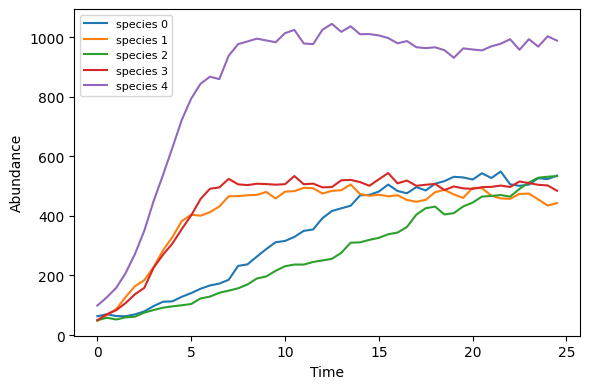

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

for i in range(5):
    ax.plot(times, x_ts[:,i], label=f"species {i}")

ax.set_xlabel("Time")
ax.set_ylabel("Abundance")
#ax.set_yscale("log")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Parallel simulation

In [3]:
import os
import pickle
import multiprocessing as mp
def save_params(params, out_dir, param_seed):
    os.makedirs(out_dir, exist_ok=True)

    params_path = os.path.join(out_dir, f"params_I{param_seed}.pkl")

    with open(params_path, "wb") as f:
        pickle.dump(params, f, protocol=pickle.HIGHEST_PROTOCOL)

    return params_path


def load_params(params_path):
    with open(params_path, "rb") as f:
        params = pickle.load(f)
    return params

In [4]:
def run_one_replicate(args):
    """
    Simulate one trajectory with the same parameter set but a different initial condition.
    """
    (
        rep,
        params,
    ) = args
    sim_seed = int(rep)
    rng = np.random.default_rng(sim_seed)
    steadystate = params["steadystate"]
    init = steadystate * rng.uniform(0, 0.5, size=steadystate.shape)
    times, x_ts = simulate_langevin(
        init=init,
        params=params,
        dt=0.01,
        T=24.5,
        tskip=50,
        seed=sim_seed,
    )

    return rep, x_ts.T # return shape (species, timepoints)

In [5]:
def run_batch_simulations(
    N,
    model_index=1,
    n_reps=100,
    n_workers=4,
    noise_type="linear",
    noise_linear=0.1,
    noise_sqrt=0.1,
):
    """
    Generate one parameter set, save it, then simulate many initial conditions
    in parallel using multiprocessing.
    """
    out_dir=f"./saved_sims/I{model_index}/"
    os.makedirs(out_dir, exist_ok=True)
    
    params = make_params(
    N,
    interaction=0.0,
    noise_type=noise_type,
    noise_linear=noise_linear,
    noise_sqrt=noise_sqrt,
    seed=model_index,
    )

    params_path = save_params(params, out_dir, model_index)

    jobs = []
    for rep in range(n_reps):
        jobs.append((rep, params))

    with mp.Pool(processes=n_workers) as pool:
        results = pool.map(run_one_replicate, jobs)

    results = sorted(results, key=lambda x: x[0])
    data = [xt for _, xt in results]
    data = np.array(data)

    np.save(f"./saved_sims/I{model_index}/data_N{N}_I{model_index}.npy", data)

## model 1: deterministic logistic model

In [36]:
if __name__ == "__main__":

    N = 10

    n_workers = mp.cpu_count()

    result = run_batch_simulations(
        N,
        model_index=1,
        n_reps=10000,
        n_workers=n_workers-1,
        noise_type="none",
        noise_linear=0,
        noise_sqrt=0,
    )


(10000, 10, 50)


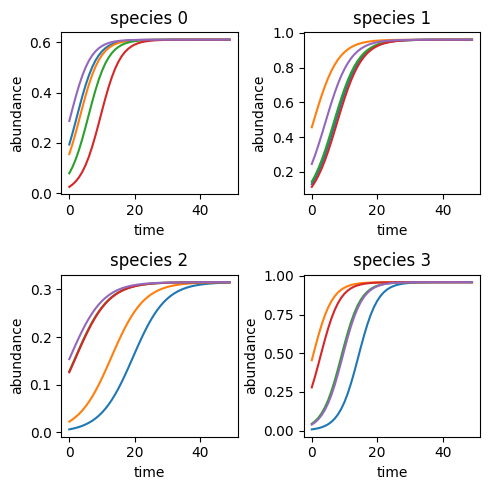

In [37]:
model_index = 1
N = 10

data = np.load(f"./saved_sims/I{model_index}/data_N{N}_I{model_index}.npy")
print(data.shape) # (n_reps, species, timepoints)
time = np.arange(0,50,1)

fig,axes=plt.subplots(2,2,figsize=(5,5,))
axes=axes.flat
for rep in range(5):
    for sp in range(4):
        ax=axes[sp]
        ax.plot(time, data[rep,sp], label=f"rep {rep}")
        ax.set_title(f"species {sp}")
        ax.set_xlabel("time")
        ax.set_ylabel("abundance")
fig.tight_layout()
plt.show()

## model 2 - 5: increasing extrinsic (linear) noise 
noise_linear = 0.01, 0.05, 0.1, 0.2

In [39]:
if __name__ == "__main__":

    N = 10

    n_workers = mp.cpu_count()

    noise_scale = {2: 0.01, 3: 0.05, 4: 0.1, 5: 0.2}

    for model_index, noise_linear in noise_scale.items():
        print(f"Running model {model_index} with noise_linear={noise_linear}...")

        result = run_batch_simulations(
            N,
            model_index=model_index,
            n_reps=10000,
            n_workers=n_workers-1,
            noise_type="linear",
            noise_linear=noise_linear,
            noise_sqrt=0,
        )


Running model 2 with noise_linear=0.01...


Running model 3 with noise_linear=0.05...
Running model 4 with noise_linear=0.1...
Running model 5 with noise_linear=0.2...


(10, 10, 50)


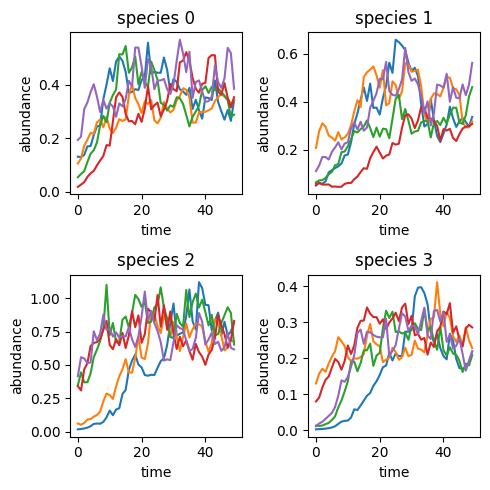

In [35]:
model_index = 2
N = 10

data = np.load(f"./saved_sims/I{model_index}/data_N{N}_I{model_index}.npy")
print(data.shape) # (n_reps, species, timepoints)
time = np.arange(0,50,1)

fig,axes=plt.subplots(2,2,figsize=(5,5,))
axes=axes.flat
for rep in range(5):
    for sp in range(4):
        ax=axes[sp]
        ax.plot(time, data[rep,sp], label=f"rep {rep}")
        ax.set_title(f"species {sp}")
        ax.set_xlabel("time")
        ax.set_ylabel("abundance")
fig.tight_layout()
plt.show()

# train-test split

In [ ]:
from sklearn.model_selection import train_test_split
np.random.seed(42)
model_index = 1
NT = np.arange(1,11,1)
for n_target in NT:
    data = np.load(f"./saved_sims/I{model_index}/data_N10_I{model_index}.npy")
    print(data.shape) # (n_reps, species, timepoints)

    X = data[:,:n_target,:]

    xmax = np.max(X)
    X = X/xmax
    print(f"{n_target}-target populations; maximum value in the original data: {xmax}, maximum value in the normalized data: {np.max(X)}")

    X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
    np.save(f"./saved_sims/I{model_index}/T{n_target}_train.npy",X_train)
    np.save(f"./saved_sims/I{model_index}/T{n_target}_test.npy",X_test)

(10000, 10, 50)
1-target populations; maximum value in the original data: 0.6094572328198905, maximum value in the normalized data: 1.0
(10000, 10, 50)
2-target populations; maximum value in the original data: 0.9603684113118331, maximum value in the normalized data: 1.0
(10000, 10, 50)
3-target populations; maximum value in the original data: 0.9603684113118331, maximum value in the normalized data: 1.0
(10000, 10, 50)
4-target populations; maximum value in the original data: 0.9603684113118331, maximum value in the normalized data: 1.0
(10000, 10, 50)
5-target populations; maximum value in the original data: 0.9603684113118331, maximum value in the normalized data: 1.0
(10000, 10, 50)
6-target populations; maximum value in the original data: 0.9603684113118331, maximum value in the normalized data: 1.0
(10000, 10, 50)
7-target populations; maximum value in the original data: 0.9603684113118331, maximum value in the normalized data: 1.0
(10000, 10, 50)
8-target populations; maximum va

In [5]:
from sklearn.model_selection import train_test_split
np.random.seed(42)
n_target = 3
model = np.arange(2,6,1)
for model_index in model:
    data = np.load(f"./saved_sims/I{model_index}/data_N10_I{model_index}.npy")
    print(data.shape) # (n_reps, species, timepoints)

    X = data[:,:n_target,:]

    xmax = np.max(X)
    X = X/xmax
    print(f"{n_target}-target populations; maximum value in the original data: {xmax}, maximum value in the normalized data: {np.max(X)}")

    X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
    np.save(f"./saved_sims/I{model_index}/T{n_target}_train.npy",X_train)
    np.save(f"./saved_sims/I{model_index}/T{n_target}_test.npy",X_test)

(10000, 10, 50)
3-target populations; maximum value in the original data: 0.891367913339999, maximum value in the normalized data: 1.0
(10000, 10, 50)
3-target populations; maximum value in the original data: 1.052367539556646, maximum value in the normalized data: 1.0
(10000, 10, 50)
3-target populations; maximum value in the original data: 1.5092653270595953, maximum value in the normalized data: 1.0
(10000, 10, 50)
3-target populations; maximum value in the original data: 2.0531601995738096, maximum value in the normalized data: 1.0


## model 6 - 9: increasing intrinsic (sqrt) noise 
noise_linear = 0.1, 0.5, 1, 2

In [13]:
if __name__ == "__main__":

    N = 10

    n_workers = mp.cpu_count()

    noise_scale = {6: 0.1, 7: 0.5, 8: 1, 9: 2}

    for model_index, noise_sqrt in noise_scale.items():
        print(f"Running model {model_index} with noise_sqrt={noise_sqrt}...")

        result = run_batch_simulations(
            N,
            model_index=model_index,
            n_reps=10000,
            n_workers=n_workers-1,
            noise_type="sqrt",
            noise_linear=0,
            noise_sqrt=noise_sqrt,
        )


Running model 6 with noise_sqrt=0.1...


Running model 7 with noise_sqrt=0.5...
Running model 8 with noise_sqrt=1...
Running model 9 with noise_sqrt=2...


(10000, 10, 50)


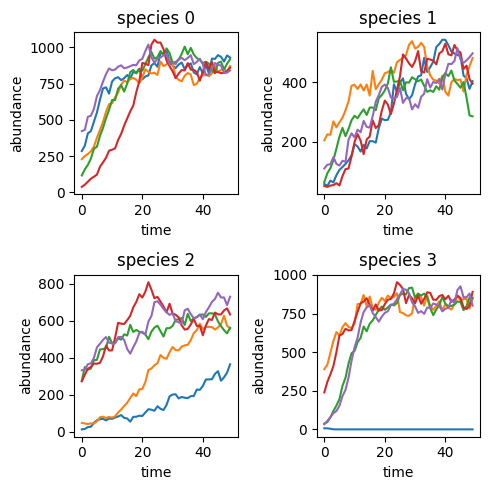

In [17]:
import matplotlib.pyplot as plt
model_index = 9
N = 10

data = np.load(f"./saved_sims/I{model_index}/data_N{N}_I{model_index}.npy")
print(data.shape) # (n_reps, species, timepoints)
time = np.arange(0,50,1)

fig,axes=plt.subplots(2,2,figsize=(5,5,))
axes=axes.flat
for rep in range(5):
    for sp in range(4):
        ax=axes[sp]
        ax.plot(time, data[rep,sp], label=f"rep {rep}")
        ax.set_title(f"species {sp}")
        ax.set_xlabel("time")
        ax.set_ylabel("abundance")
fig.tight_layout()
plt.show()

# train-test split

In [18]:
from sklearn.model_selection import train_test_split
np.random.seed(42)
n_target = 3
model = np.arange(6,10,1)
for model_index in model:
    data = np.load(f"./saved_sims/I{model_index}/data_N10_I{model_index}.npy")
    print(data.shape) # (n_reps, species, timepoints)

    X = data[:,:n_target,:]

    xmax = np.max(X)
    X = X/xmax
    print(f"{n_target}-target populations; maximum value in the original data: {xmax}, maximum value in the normalized data: {np.max(X)}")

    X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
    np.save(f"./saved_sims/I{model_index}/T{n_target}_train.npy",X_train)
    np.save(f"./saved_sims/I{model_index}/T{n_target}_test.npy",X_test)

(10000, 10, 50)
3-target populations; maximum value in the original data: 641.5554097896821, maximum value in the normalized data: 1.0
(10000, 10, 50)
3-target populations; maximum value in the original data: 999.2090160159813, maximum value in the normalized data: 1.0
(10000, 10, 50)
3-target populations; maximum value in the original data: 1162.1622043872903, maximum value in the normalized data: 1.0
(10000, 10, 50)
3-target populations; maximum value in the original data: 1155.1386133649437, maximum value in the normalized data: 1.0
